In [1]:
import pandas as pd
import os, sys, glob, re

species = "human"

def extract_genome_and_species_string(path):
    match = re.search(r'To([A-Za-z0-9]+)(?:_([A-Za-z0-9]+))?', path)
    if match:
        genome = match.group(1).lower()
        species = match.group(2).lower() if match.group(2) else ""
        return f"{genome}_{species}" if species else genome
    return ""

species_naming = {
    "hg38": "human",
    "rhemac10": "macaque",
    "hmba_marmoset": "marmoset",
    "mm10": "mouse",
}

## Find liftover results
liftoverDir = f"/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/SpinalCord/manuscript/ATAC/{species}/Consensus_peaks"
liftoverResults = glob.glob(f"{liftoverDir}/merged_peaks_with_names_*.bed")

liftoverDf = pd.DataFrame()

## Read in liftover results
for file in liftoverResults:
    print(f"Reading {file}")
    liftover = pd.read_csv(file, sep="\t", comment="#", header=None)
    liftover.columns = ["chrom", "start", "end", f"{species}_peak_name"]
    ## Identify the genome and species from the filename
    match = extract_genome_and_species_string(file)
    species_name = species_naming.get(match, "unknown")
    ## Add species information
    liftover["speciesFrom"] = species
    liftover["speciesTo"] = species_name
    ## Check if file is liftOver or unmapped
    if "unmapped" in file:
        liftover["liftOver"] = "unmapped"
    else:
        liftover["liftOver"] = "mapped"
    ## Combine into a results dataframe
    liftoverDf = pd.concat([liftoverDf, liftover], ignore_index=True)

Reading /allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/SpinalCord/manuscript/ATAC/human/Consensus_peaks/merged_peaks_with_names_liftOver_hg38ToRheMac10.bed
Reading /allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/SpinalCord/manuscript/ATAC/human/Consensus_peaks/merged_peaks_with_names_liftOver_hg38ToMm10.bed
Reading /allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/SpinalCord/manuscript/ATAC/human/Consensus_peaks/merged_peaks_with_names_unmapped_hg38ToHMBA_marmoset.bed
Reading /allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/SpinalCord/manuscript/ATAC/human/Consensus_peaks/merged_peaks_with_names_unmapped_hg38ToRheMac10.bed
Reading /allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/SpinalCord/manuscript/ATAC/human/Consensus_peaks/merged_peaks_with_names_liftOver_hg38ToHMBA_marmoset.bed
Reading /allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/SpinalCord/manuscript/ATAC/human/Consensus_peaks/merged_peaks_with_names_unmapped_hg38T

In [ ]:
## Identify conservation levels

In [3]:
##
human_df = liftoverDf[liftoverDf["speciesFrom"] == species].copy()
pivot = human_df.pivot_table(
    index=f"{species}_peak_name",
    columns="speciesTo",
    values="liftOver",
    aggfunc="first" ## Should be fine since there's only one entry per peak per species
)

## All species (excluding human) that were targeted
target_species = [s for s in pivot.columns if s != "human"]

## Boolean mask: All target species must be "unmapped"
human_specific_mask = (pivot[target_species] == "unmapped").all(axis=1)
human_specific_peaks = pivot[human_specific_mask].index.tolist()

## Identify the set of shared peaks mapped in all species
mapped_in_all_mask = (pivot[["macaque", "marmoset"]] == "mapped").all(axis=1)
primate_peaks = pivot[mapped_in_all_mask].index.tolist()

## Identify the set of shared peaks mapped in all species
mapped_in_all_mask = (pivot[target_species] == "mapped").all(axis=1)
mammalian_peaks = pivot[mapped_in_all_mask].index.tolist()

print(f"Number of human-specific peaks: {len(human_specific_peaks)}")
print(f"Number of peaks shared with primate species: {len(primate_peaks)}")
print(f"Number of peaks shared with all species: {len(mammalian_peaks)}")

Number of human-specific peaks: 16397
Number of peaks shared with primate species: 498938
Number of peaks shared with all species: 370420


In [ ]:
## Identify cell-type level conservation

In [ ]:
## At this point we need to bring in cell type activity information
peak_table = pd.DataFrame()
for species in ["human", "macaque", "mouse"]:
    species_peak_table = pd.read_csv(f"/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/SpinalCord/manuscript/ATAC/{species}/Consensus_peaks/Group_by_peaks.csv")
    species_peak_table["species"] = species
    peak_table = pd.concat([peak_table, species_peak_table], ignore_index=True)


In [ ]:
## Plot!

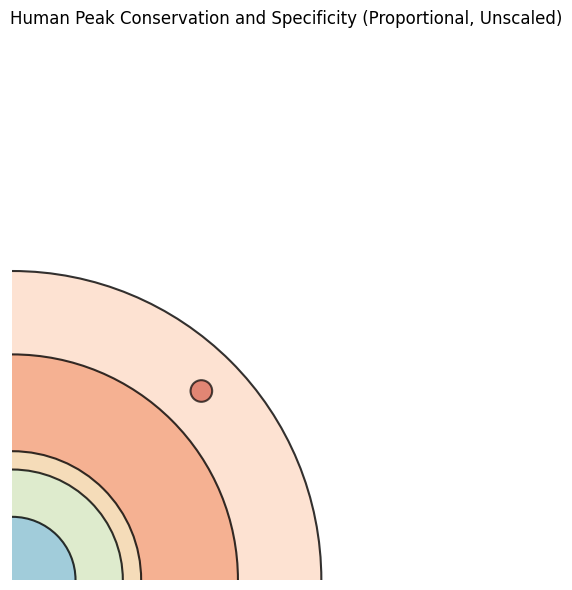

In [5]:
## Plot!
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

# Input data
labels = [
    ("Human", 384412),
    ("Mammal level 0", 204921),
    ("Mammal level 1", 66781),
    ("Mammal level 2", 49134),
    ("Mammal level 3", 16068),
]
specific_label = ("Specific", 7532)

# Convert count to radius (area ∝ count)
def area_to_radius(area):
    return np.sqrt(area / np.pi)

# Get all radii proportional to the largest count (human)
max_area = labels[0][1]
radii = [area_to_radius(n / max_area) for _, n in labels]
specific_radius = area_to_radius(specific_label[1] / max_area)

# Plot setup
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.axis('off')

center = (0, 0)
colors = ["#fddbc7", "#f4a582", "#f6e8c3", "#d9f0d3", "#92c5de"]

# Draw nested conservation bubbles
for i, ((label, count), r, color) in enumerate(zip(labels, radii, colors)):
    circ = Circle(center, r, facecolor=color, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.add_patch(circ)

# Ensure "Specific" fits inside Human but outside Mammal 0
human_radius = radii[0]
mammal0_radius = radii[1]
margin = 0.01

min_d = mammal0_radius + specific_radius + margin
max_d = human_radius - specific_radius - margin

if min_d < max_d:
    raise ValueError("Specific circle cannot fit between Mammal 0 and Human with current proportions.")

# Place "Specific" at angle (e.g. 45 degrees) at midpoint distance
specific_distance = (min_d + max_d) / 2
angle_rad = np.pi / 4
x = specific_distance * np.cos(angle_rad)
y = specific_distance * np.sin(angle_rad)
specific_center = (x, y)

# Draw "Specific"
specific_color = "#d6604d"
specific_circle = Circle(specific_center, specific_radius/4, facecolor=specific_color, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.add_patch(specific_circle)

plt.title("Human Peak Conservation and Specificity (Proportional, Unscaled)", fontsize=12)
plt.tight_layout()
plt.show()